# Visualizations & Final Report
## AI-Based Wage Gap Detection in India

Comprehensive dashboard of all findings.
Run this notebook last, after all other notebooks have been executed.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import os

sns.set_style('whitegrid')
plt.rcParams.update({'figure.figsize': (14, 7), 'font.size': 11})
os.makedirs('outputs', exist_ok=True)

# Load all outputs produced by earlier notebooks
df        = pd.read_csv('data/wage_gap_data_with_severity.csv')
viol_df   = pd.read_csv('outputs/all_violations_detailed.csv')
law_sum   = pd.read_csv('outputs/law_violation_summary.csv')
state_sum = pd.read_csv('outputs/state_violation_summary.csv')
model_res = pd.read_csv('outputs/model_comparison_final.csv', index_col=0)

print(f'Dataset       : {df.shape[0]:,} workers')
print(f'Violations    : {len(viol_df):,}')
print(f'Models loaded : {list(model_res.index)}')

Dataset       : 50,000 workers
Violations    : 92,551
Models loaded : ['Logistic Regression', 'Random Forest', 'Gradient Boosting', 'Ensemble (LR+RF+GB)', 'Ensemble', 'QML (VQC)']


## Figure 1: Overview Dashboard (6 panels)

C:\Users\rasgu\AppData\Local\Temp\ipykernel_12860\2720443543.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax5.set_xticklabels(state_underpay.index, rotation=45, ha='right')


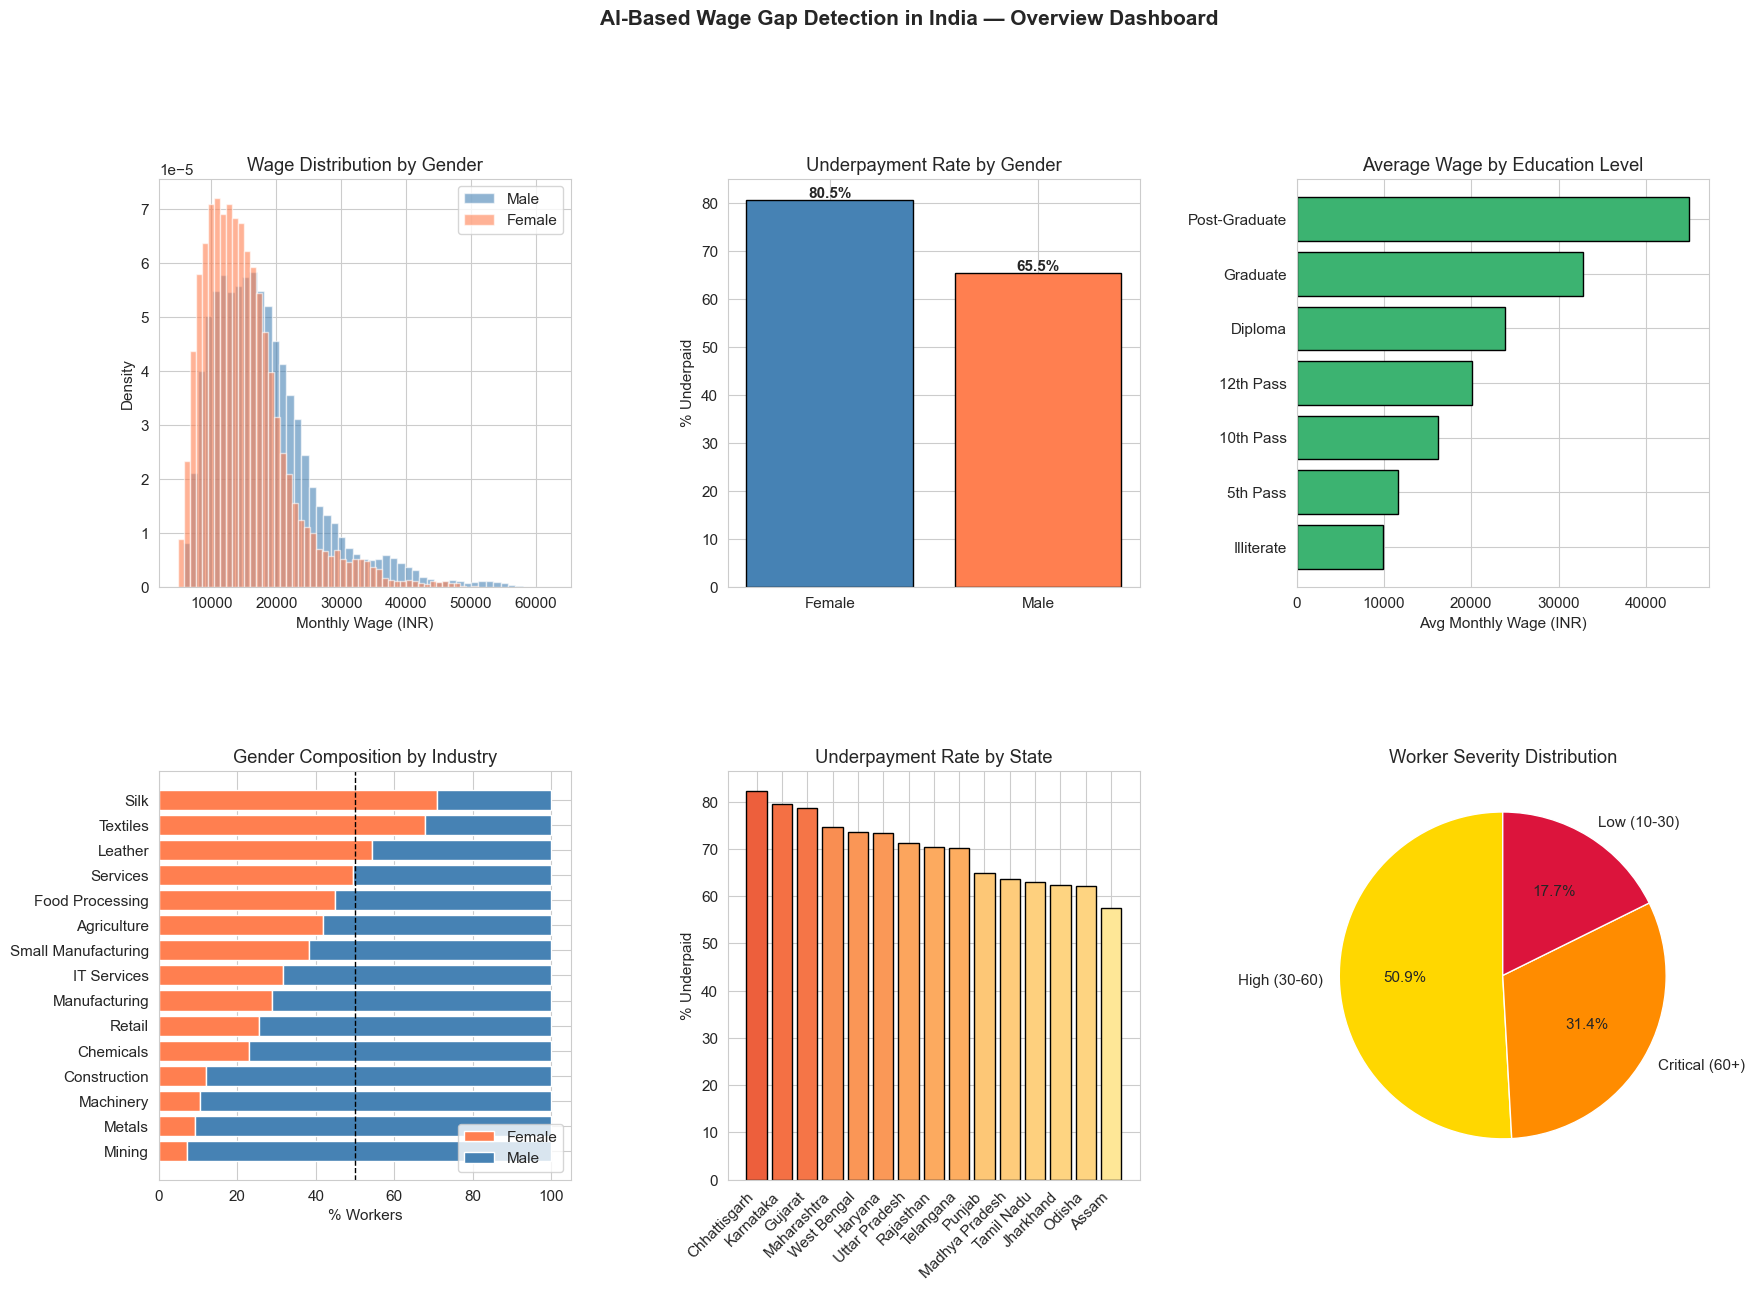

Saved: outputs/01_overview_dashboard.png


In [2]:
fig = plt.figure(figsize=(20, 13))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

# 1. Wage distribution by gender
ax1 = fig.add_subplot(gs[0, 0])
for gender, color in [('Male', 'steelblue'), ('Female', 'coral')]:
    data = df[df['gender'] == gender]['actual_monthly_wage']
    ax1.hist(data, bins=50, alpha=0.6, color=color, label=gender, density=True)
ax1.set_title('Wage Distribution by Gender')
ax1.set_xlabel('Monthly Wage (INR)')
ax1.set_ylabel('Density')
ax1.legend()

# 2. Underpayment rate by gender
ax2 = fig.add_subplot(gs[0, 1])
underpay_gender = df.groupby('gender')['is_underpaid'].mean() * 100
bars = ax2.bar(underpay_gender.index, underpay_gender.values,
               color=['steelblue', 'coral'], edgecolor='black')
for bar, val in zip(bars, underpay_gender.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', fontweight='bold')
ax2.set_title('Underpayment Rate by Gender')
ax2.set_ylabel('% Underpaid')
ax2.set_ylim(0, 85)

# 3. Average wage by education
ax3 = fig.add_subplot(gs[0, 2])
edu_order = ['Illiterate','5th Pass','10th Pass','12th Pass','Diploma','Graduate','Post-Graduate']
edu_wages = df.groupby('education_level')['actual_monthly_wage'].mean().reindex(edu_order)
ax3.barh(edu_order, edu_wages.values, color='mediumseagreen', edgecolor='black')
ax3.set_title('Average Wage by Education Level')
ax3.set_xlabel('Avg Monthly Wage (INR)')

# 4. Industry composition with gender split (replaces plain underpayment bar)
ax4 = fig.add_subplot(gs[1, 0])
ind_gender = df.pivot_table(
    values='worker_id', index='industry', columns='gender', aggfunc='count', fill_value=0
)
ind_gender = ind_gender.div(ind_gender.sum(axis=1), axis=0) * 100
ind_gender = ind_gender.sort_values('Female', ascending=True)
ax4.barh(ind_gender.index, ind_gender['Female'], color='coral',   label='Female')
ax4.barh(ind_gender.index, ind_gender['Male'],   left=ind_gender['Female'],
         color='steelblue', label='Male')
ax4.axvline(50, color='black', linestyle='--', linewidth=1)
ax4.set_title('Gender Composition by Industry')
ax4.set_xlabel('% Workers')
ax4.legend(loc='lower right')

# 5. Top states by underpayment rate
ax5 = fig.add_subplot(gs[1, 1])
state_underpay = (
    df.groupby('state')['is_underpaid'].mean() * 100
).sort_values(ascending=False)
ax5.bar(state_underpay.index, state_underpay.values,
        color=plt.cm.RdYlGn_r(state_underpay.values / 100), edgecolor='black')
ax5.set_xticklabels(state_underpay.index, rotation=45, ha='right')
ax5.set_title('Underpayment Rate by State')
ax5.set_ylabel('% Underpaid')

# 6. Severity score distribution
ax6 = fig.add_subplot(gs[1, 2])
sev_counts = df[df['severity_score'] > 0]['severity_band'].value_counts()
ax6.pie(sev_counts.values, labels=sev_counts.index, autopct='%1.1f%%',
        startangle=90, colors=['#FFD700','#FF8C00','#DC143C','#8B0000'])
ax6.set_title('Worker Severity Distribution')

plt.suptitle('AI-Based Wage Gap Detection in India — Overview Dashboard',
             fontsize=15, fontweight='bold', y=1.01)
plt.savefig('outputs/01_overview_dashboard.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: outputs/01_overview_dashboard.png')


## Figure 2: Gender Wage Gap Deep Dive

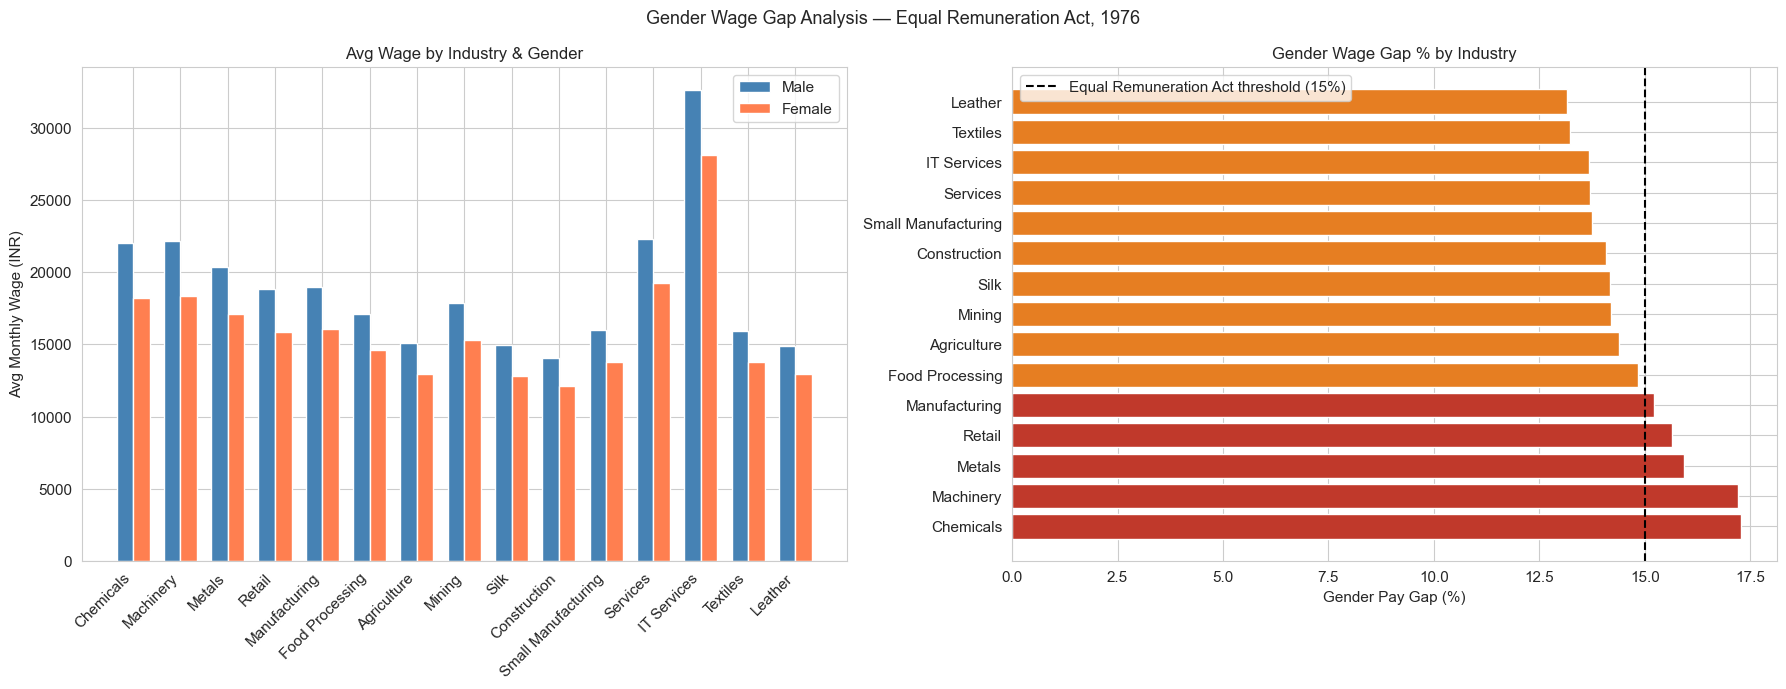

Saved: outputs/02_gender_wage_gap.png


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

gender_ind = df.pivot_table(
    values='actual_monthly_wage', index='industry', columns='gender', aggfunc='mean'
)
gender_ind['gap_pct'] = (
    (gender_ind['Male'] - gender_ind['Female']) / gender_ind['Male'] * 100
)
gender_ind = gender_ind.sort_values('gap_pct', ascending=False)

x = np.arange(len(gender_ind))
w = 0.35
axes[0].bar(x - w/2, gender_ind['Male'],   width=w, label='Male',   color='steelblue')
axes[0].bar(x + w/2, gender_ind['Female'], width=w, label='Female', color='coral')
axes[0].set_xticks(x)
axes[0].set_xticklabels(gender_ind.index, rotation=45, ha='right')
axes[0].set_title('Avg Wage by Industry & Gender', fontsize=12)
axes[0].set_ylabel('Avg Monthly Wage (INR)')
axes[0].legend()

colors_gap = ['#c0392b' if v > 15 else '#e67e22' for v in gender_ind['gap_pct']]
axes[1].barh(gender_ind.index, gender_ind['gap_pct'], color=colors_gap)
axes[1].axvline(15, color='black', linestyle='--', lw=1.5,
                label='Equal Remuneration Act threshold (15%)')
axes[1].set_title('Gender Wage Gap % by Industry', fontsize=12)
axes[1].set_xlabel('Gender Pay Gap (%)')
axes[1].legend()

plt.suptitle('Gender Wage Gap Analysis — Equal Remuneration Act, 1976', fontsize=13)
plt.tight_layout()
plt.savefig('outputs/02_gender_wage_gap.png', dpi=120)
plt.show()
print('Saved: outputs/02_gender_wage_gap.png')


## Figure 3: Law Violation Analysis

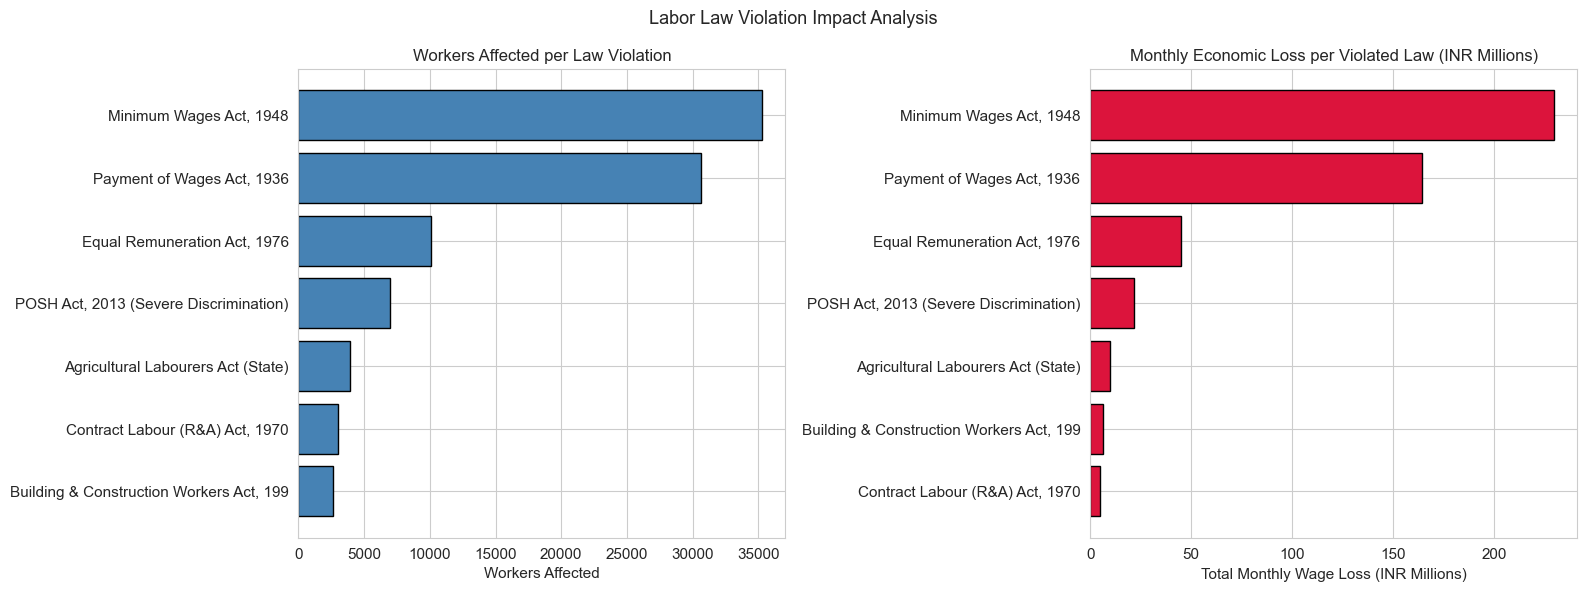

Saved: outputs/03_law_violation_analysis.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

law_plot = law_sum.sort_values('workers_affected', ascending=True).tail(8)
axes[0].barh(law_plot['law_name'].str[:40], law_plot['workers_affected'],
             color='steelblue', edgecolor='black')
axes[0].set_title('Workers Affected per Law Violation', fontsize=12)
axes[0].set_xlabel('Workers Affected')

law_plot2 = law_sum.sort_values('total_loss_inr', ascending=True).tail(8)
axes[1].barh(law_plot2['law_name'].str[:40],
             law_plot2['total_loss_inr'] / 1e6,
             color='crimson', edgecolor='black')
axes[1].set_title('Monthly Economic Loss per Violated Law (INR Millions)', fontsize=12)
axes[1].set_xlabel('Total Monthly Wage Loss (INR Millions)')

plt.suptitle('Labor Law Violation Impact Analysis', fontsize=13)
plt.tight_layout()
plt.savefig('outputs/03_law_violation_analysis.png', dpi=120)
plt.show()
print('Saved: outputs/03_law_violation_analysis.png')

## Figure 4: Model Performance Comparison

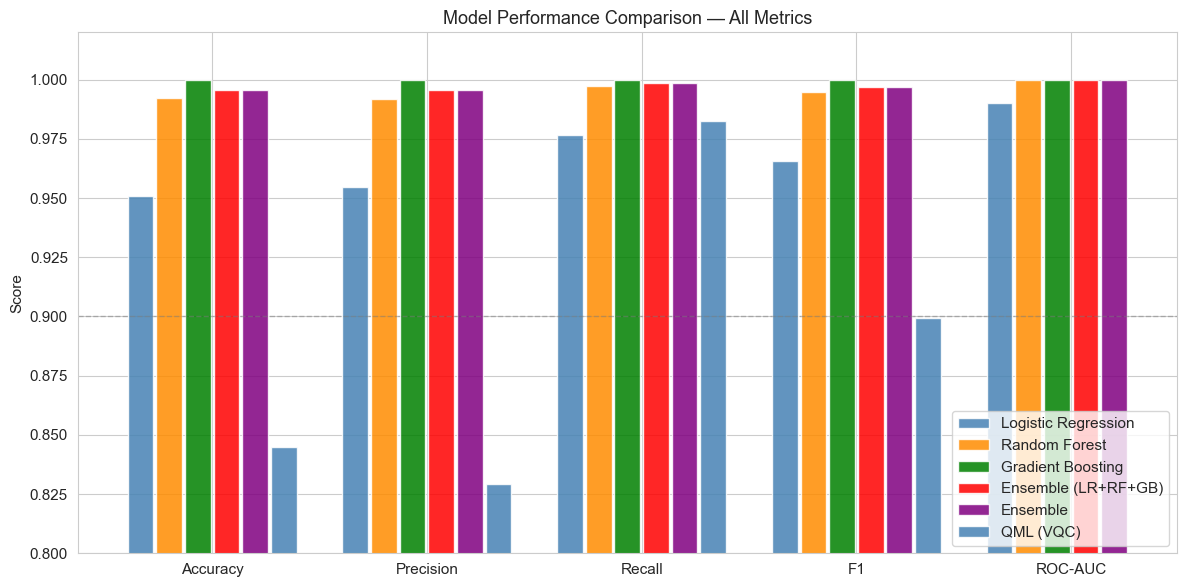

Saved: outputs/04_model_comparison.png


In [5]:
fig, ax = plt.subplots(figsize=(12, 6))

metrics  = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
x        = np.arange(len(metrics))
n_models = len(model_res)
width    = 0.8 / n_models
colors   = ['steelblue', 'darkorange', 'green', 'red', 'purple']

for i, (model_name, row) in enumerate(model_res.iterrows()):
    vals = [row.get(m, np.nan) for m in metrics]
    ax.bar(x + i * width - 0.4 + width / 2,
           vals, width=width * 0.9,
           label=model_name,
           color=colors[i % len(colors)],
           alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0.80, 1.02)
ax.set_title('Model Performance Comparison — All Metrics', fontsize=13)
ax.set_ylabel('Score')
ax.legend(loc='lower right')
ax.axhline(0.9, color='gray', linestyle='--', linewidth=1, alpha=0.5)

plt.tight_layout()
plt.savefig('outputs/04_model_comparison.png', dpi=120)
plt.show()
print('Saved: outputs/04_model_comparison.png')

## Figure 5: State-Level Enforcement Analysis

C:\Users\rasgu\AppData\Local\Temp\ipykernel_12860\2251786543.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(state_sorted['state'], rotation=45, ha='right')


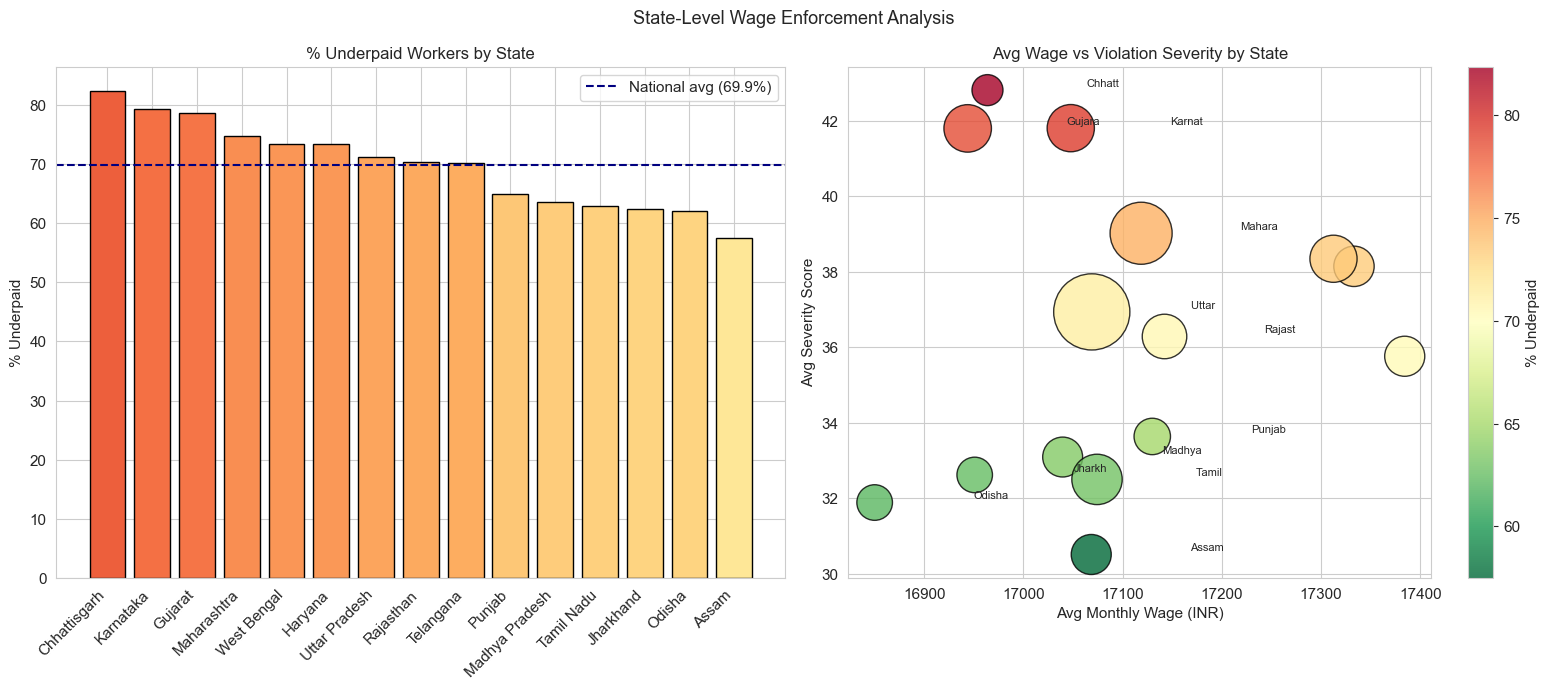

Saved: outputs/05_state_enforcement.png


In [6]:
state_pivot = df.groupby('state').agg(
    total_workers=('worker_id', 'count'),
    pct_underpaid=('is_underpaid', 'mean'),
    avg_severity=('severity_score', 'mean'),
    avg_wage=('actual_monthly_wage', 'mean')
).reset_index()
state_pivot['pct_underpaid'] *= 100

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

state_sorted = state_pivot.sort_values('pct_underpaid', ascending=False)
axes[0].bar(
    state_sorted['state'],
    state_sorted['pct_underpaid'],
    color=plt.cm.RdYlGn_r(state_sorted['pct_underpaid'] / 100),
    edgecolor='black'
)
axes[0].axhline(
    state_pivot['pct_underpaid'].mean(),
    color='navy', linestyle='--',
    label=f'National avg ({state_pivot["pct_underpaid"].mean():.1f}%)'
)
axes[0].set_xticklabels(state_sorted['state'], rotation=45, ha='right')
axes[0].set_title('% Underpaid Workers by State', fontsize=12)
axes[0].set_ylabel('% Underpaid')
axes[0].legend()

sc = axes[1].scatter(
    state_pivot['avg_wage'],
    state_pivot['avg_severity'],
    s=state_pivot['total_workers'] / 3,
    c=state_pivot['pct_underpaid'],
    cmap='RdYlGn_r', alpha=0.8, edgecolors='black'
)
for _, row in state_pivot.iterrows():
    axes[1].annotate(
        row['state'][:6],
        (row['avg_wage'] + 100, row['avg_severity'] + 0.1),
        fontsize=8
    )
plt.colorbar(sc, ax=axes[1], label='% Underpaid')
axes[1].set_title('Avg Wage vs Violation Severity by State', fontsize=12)
axes[1].set_xlabel('Avg Monthly Wage (INR)')
axes[1].set_ylabel('Avg Severity Score')

plt.suptitle('State-Level Wage Enforcement Analysis', fontsize=13)
plt.tight_layout()
plt.savefig('outputs/05_state_enforcement.png', dpi=120)
plt.show()
print('Saved: outputs/05_state_enforcement.png')

## Figure 6: QML Policy Recommendations (if available)

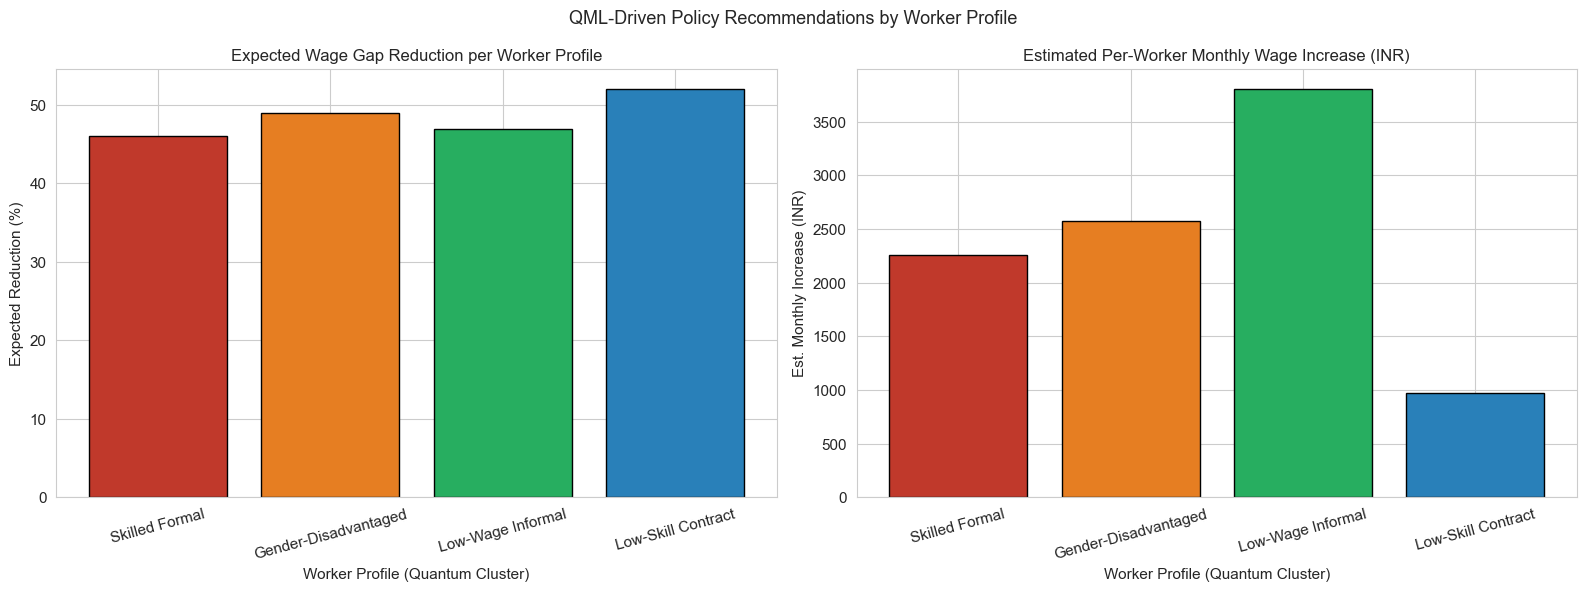

Saved: outputs/06_policy_recommendations.png


In [7]:
if os.path.exists('outputs/qml_policy_recommendations.csv'):
    policy_df = pd.read_csv('outputs/qml_policy_recommendations.csv')

    # Use cluster_label if available, else fall back to cluster id
    x_label = 'cluster_label' if 'cluster_label' in policy_df.columns else 'cluster'

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    colors = ['#c0392b','#e67e22','#27ae60','#2980b9']
    axes[0].bar(policy_df[x_label], policy_df['total_impact_pct'],
                color=colors[:len(policy_df)], edgecolor='black')
    axes[0].set_title('Expected Wage Gap Reduction per Worker Profile', fontsize=12)
    axes[0].set_xlabel('Worker Profile (Quantum Cluster)')
    axes[0].set_ylabel('Expected Reduction (%)')
    axes[0].tick_params(axis='x', rotation=15)

    axes[1].bar(policy_df[x_label], policy_df['est_wage_increase'],
                color=colors[:len(policy_df)], edgecolor='black')
    axes[1].set_title('Estimated Per-Worker Monthly Wage Increase (INR)', fontsize=12)
    axes[1].set_xlabel('Worker Profile (Quantum Cluster)')
    axes[1].set_ylabel('Est. Monthly Increase (INR)')
    axes[1].tick_params(axis='x', rotation=15)

    plt.suptitle('QML-Driven Policy Recommendations by Worker Profile', fontsize=13)
    plt.tight_layout()
    plt.savefig('outputs/06_policy_recommendations.png', dpi=120)
    plt.show()
    print('Saved: outputs/06_policy_recommendations.png')
else:
    print('Run Quantum_ML.ipynb first to generate policy recommendations.')


## Final Summary Report

In [8]:
total     = len(df)
underpaid = df['is_underpaid'].sum()
female_avg = df[df['gender']=='Female']['actual_monthly_wage'].mean()
male_avg   = df[df['gender']=='Male']['actual_monthly_wage'].mean()
gender_gap = (male_avg - female_avg) / male_avg * 100

print('=' * 65)
print('  AI-BASED WAGE GAP DETECTION IN INDIA — FINAL REPORT')
print('=' * 65)
print(f'  Total workers analysed   : {total:,}')
print(f'  Workers underpaid        : {underpaid:,} ({underpaid/total*100:.1f}%)')
print(f'  Gender wage gap          : {gender_gap:.1f}% (Female earns less)')
print(f'  Total law violations     : {len(viol_df):,}')
print(f'  Workers with violations  : {viol_df["worker_id"].nunique():,}')
print()
print('  INDUSTRY REPRESENTATION (top 5):')
for ind, pct in (df['industry'].value_counts(normalize=True)*100).head(5).items():
    print(f'    {ind:25s} {pct:.1f}%')
print()
print('  GENDER SPLIT BY INDUSTRY (% Female, top 5 most female):')
fem_by_ind = (df.groupby('industry')['gender']
               .apply(lambda x: (x=='Female').mean()*100)
               .sort_values(ascending=False))
for ind, pct in fem_by_ind.head(5).items():
    print(f'    {ind:25s} {pct:.1f}% female')
print()
print('  TOP 3 VIOLATED LAWS:')
for _, row in law_sum.head(3).iterrows():
    print(f'    {str(row["law_name"])[:50]:50s} -> {int(row["workers_affected"]):,} workers')
print()
best = model_res['F1'].idxmax()
print(f'  BEST ML MODEL: {best}')
print(f'    F1={model_res.loc[best,"F1"]:.4f}, AUC={model_res.loc[best,"ROC-AUC"]:.4f}')
print()
print('  OUTPUT FILES:')
for f in sorted(os.listdir('outputs')):
    if f.endswith(('.png','.csv')):
        print(f'    outputs/{f}')
print('=' * 65)


  AI-BASED WAGE GAP DETECTION IN INDIA — FINAL REPORT
  Total workers analysed   : 50,000
  Workers underpaid        : 35,285 (70.6%)
  Gender wage gap          : 16.4% (Female earns less)
  Total law violations     : 92,551
  Workers with violations  : 35,285

  INDUSTRY REPRESENTATION (top 5):
    Agriculture               20.1%
    Construction              12.3%
    Manufacturing             9.9%
    Retail                    8.0%
    Textiles                  6.9%

  GENDER SPLIT BY INDUSTRY (% Female, top 5 most female):
    Silk                      70.8% female
    Textiles                  67.8% female
    Leather                   54.4% female
    Services                  49.4% female
    Food Processing           44.9% female

  TOP 3 VIOLATED LAWS:
    Minimum Wages Act, 1948                            -> 35,285 workers
    Payment of Wages Act, 1936                         -> 30,600 workers
    Equal Remuneration Act, 1976                       -> 10,113 workers

  BEST M